In [2]:
pip install shap xgboost pandas scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\kpuni\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
# Import necessary libraries
import shap
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [4]:
# Load your dataset (replace with your actual dataset)
data = pd.read_csv("C:/Users/kpuni/Downloads/healthcare_dataset.csv (3)/healthcare_dataset.csv")  # Replace with your dataset path

In [5]:
data

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [6]:
# Define target column and features
target_column = "Test Results"  # Replace with your target column
features = ["Age", "Gender", "Blood Type", "Medical Condition","Billing Amount", "Admission Type"] 

In [7]:
# Encode categorical variables
label_encoders = {}
for column in features:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

In [8]:
# Encode target column
target_encoder = LabelEncoder()
data[target_column] = target_encoder.fit_transform(data[target_column])

In [9]:
# Split dataset
X = data[features]
y = data[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric="mlogloss", random_state=42, use_label_encoder=False)
xgb_model.fit(X_train, y_train)

C:\Users\kpuni\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:40:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [11]:
# Evaluate the model
y_pred = xgb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.355045045045045


In [12]:
# SHAP Analysis
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

100%|===================| 33260/33300 [12:05<00:00]        

In [13]:
print(f"Shape of SHAP values: {shap_values.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of SHAP values: (11100, 6, 3)
Shape of X_test: (11100, 6)


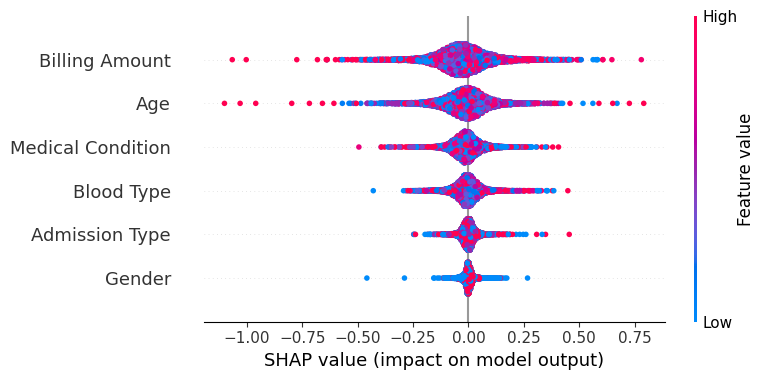

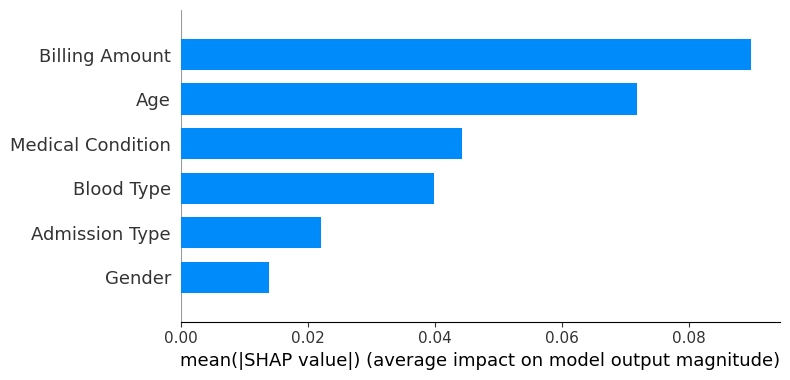

In [14]:
# Visualize SHAP values for class 0
class_index = 0  # Change this to visualize another class
shap.summary_plot(shap_values[:, :, class_index], X_test)

# Bar plot for the same class
shap.summary_plot(shap_values[:, :, class_index], X_test, plot_type="bar")


Visualizing SHAP values for class 0


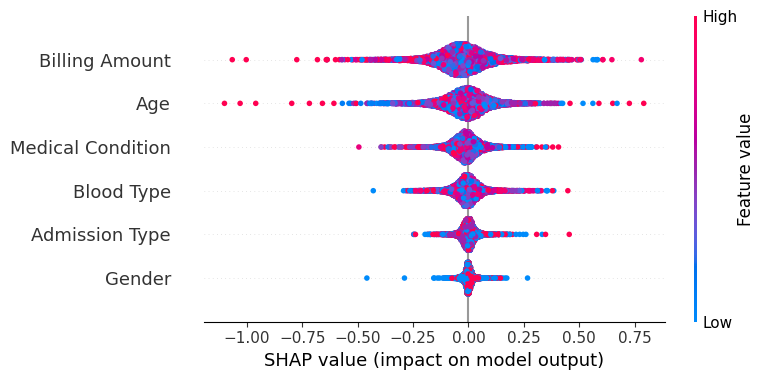

Visualizing SHAP values for class 1


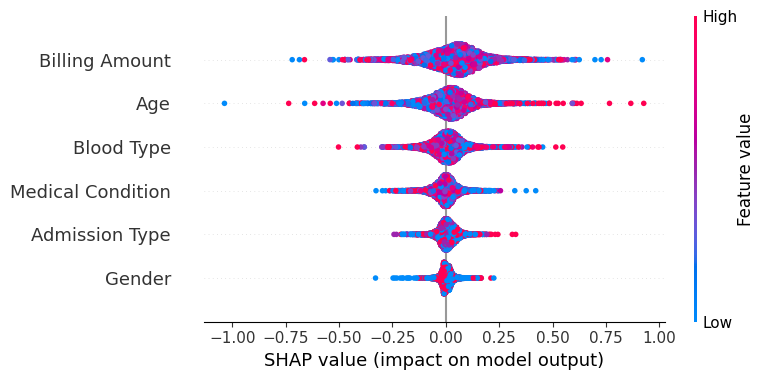

Visualizing SHAP values for class 2


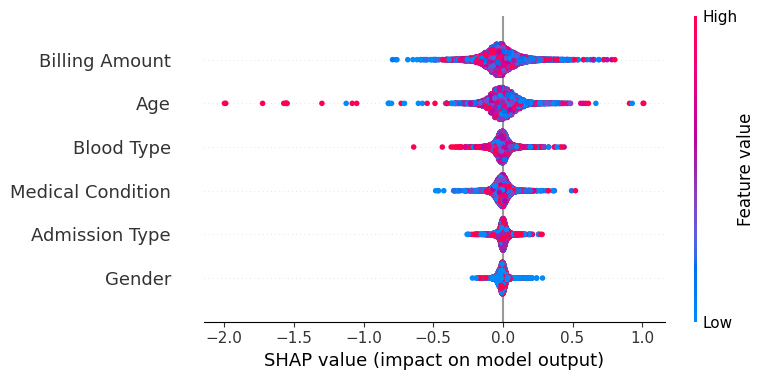

In [15]:
for class_index in range(shap_values.shape[2]):
    print(f"Visualizing SHAP values for class {class_index}")
    shap.summary_plot(shap_values[:, :, class_index], X_test, show=True)

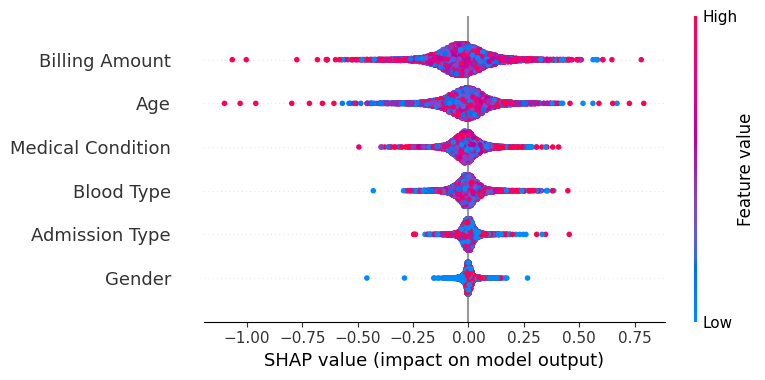

In [16]:
shap.summary_plot(shap_values[:, :, 0], X_test)

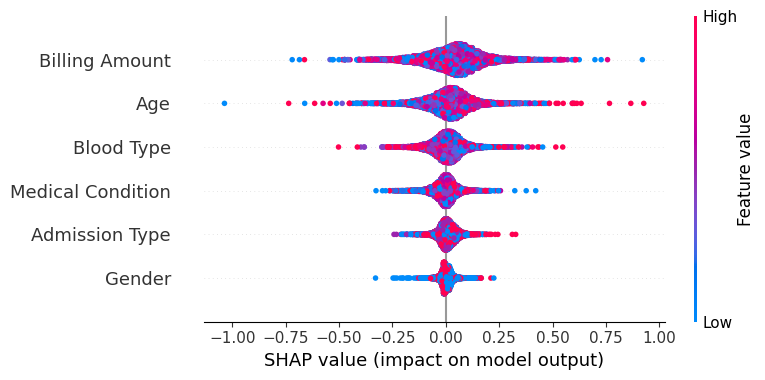

In [17]:
shap.summary_plot(shap_values[:, :, 1], X_test)

In [18]:
print(type(shap_values))  # Should be a shap.Explanation object
print(shap_values.shape)  # Shape of the SHAP values


<class 'shap._explanation.Explanation'>
(11100, 6, 3)


In [19]:
print(shap_values[0].shape)  # Should correspond to the number of features


(6, 3)


In [20]:
print("Shape of SHAP values:", shap_values.shape)
print("Shape of X_test:", X_test.shape)

Shape of SHAP values: (11100, 6, 3)
Shape of X_test: (11100, 6)


In [21]:
# Extract SHAP values for class 0
class_index = 0
shap_values_class = shap_values[:, :, class_index]

In [22]:
print("SHAP values shape for class:", shap_values_class.shape)
print("X_test shape:", X_test.shape)
print("Feature names in X_test:", X_test.columns)

SHAP values shape for class: (11100, 6)
X_test shape: (11100, 6)
Feature names in X_test: Index(['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Billing Amount',
       'Admission Type'],
      dtype='object')


In [23]:
print("Feature names in X_test:", X_test.columns.tolist())

Feature names in X_test: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Billing Amount', 'Admission Type']


In [24]:
feature_name = "Age"  # Replace with your feature
if feature_name not in X_test.columns:
    print(f"Feature '{feature_name}' is missing!")

In [25]:
feature_index = X_test.columns.get_loc(feature_name)  # Replace with your feature name

In [26]:
feature_name = X_test.columns[feature_index]  # Replace with your index

In [27]:
import numpy as np

In [28]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [29]:
# Check the type of shap_values
print("Type of shap_values:", type(shap_values))

# If it's a list, check the type of elements inside
if isinstance(shap_values, list):
    for i, class_shap in enumerate(shap_values):
        print(f"Class {i}: Type of SHAP values: {type(class_shap)}")
        print(f"Class {i}: Shape of SHAP values:", getattr(class_shap, "shape", "Not an array"))

Type of shap_values: <class 'shap._explanation.Explanation'>


In [30]:
print("Type of shap_values:", type(shap_values))
print("Attributes of shap_values:", dir(shap_values))

Type of shap_values: <class 'shap._explanation.Explanation'>
Attributes of shap_values: ['__add__', '__class__', '__copy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__mul__', '__ne__', '__new__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__rsub__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__weakref__', '_apply_binary_operator', '_flatten_feature_names', '_numpy_func', '_s', '_use_data_as_feature_names', 'abs', 'argsort', 'base_values', 'clustering', 'cohorts', 'compute_time', 'data', 'display_data', 'error_std', 'feature_names', 'flip', 'hclust', 'hierarchical_values', 'hstack', 'identity', 'instance_names', 'lower_bounds', 'main_effects', 'max', 'mean', 'min', 'op_history', 'output_dims', 'output_indexes', 'output_names', 

In [31]:
shap_values_array = shap_values.values
print("Shape of SHAP values:", shap_values_array.shape)

Shape of SHAP values: (11100, 6, 3)


In [32]:
import numpy as np
print("Any NaNs in SHAP values:", np.isnan(shap_values_array).any())

Any NaNs in SHAP values: False


In [33]:
class_index = 0  # Choose the desired class
shap_values_class = shap_values_array[:, :, class_index]
print("Shape of SHAP values for class:", shap_values_class.shape)

Shape of SHAP values for class: (11100, 6)


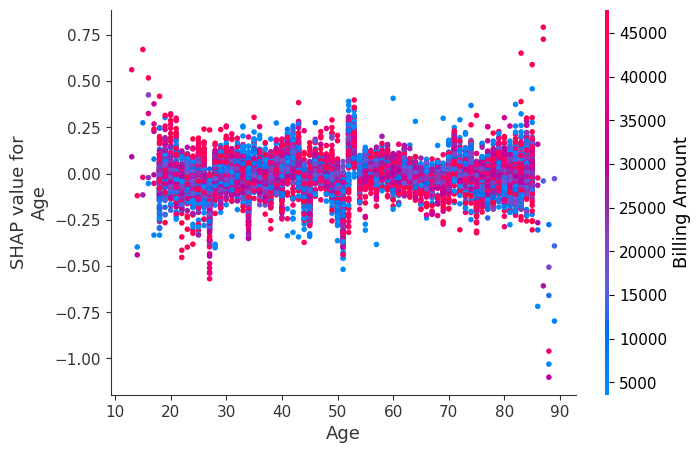

In [34]:
shap.dependence_plot("Age", shap_values_class, X_test)

In [35]:
print("Missing values in X_test:", X_test.isnull().sum())
print("Any NaNs in SHAP values:", np.isnan(shap_values).any())


Missing values in X_test: Age                  0
Gender               0
Blood Type           0
Medical Condition    0
Billing Amount       0
Admission Type       0
dtype: int64


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''